# Predicting Student Health Risk (Kaggle PS S6E7) — EDA

**Task:** 3-class classification of `health_condition` (`at-risk`, `fit`, `unhealthy`) from 7 numeric
behavioural + 6 categorical lifestyle features. **Metric: Balanced Accuracy Score** (mean of per-class
recall). Because the target is heavily imbalanced (`at-risk` ~86%), the naive "always at-risk"
prediction scores only **1/3 = 0.333** — every class matters equally, so minority-class recall is
where the score is won.

This notebook answers: **class balance · numeric & categorical distributions · missingness (is it
informative?) · feature↔target signal (per-class means, mutual information, single-feature balanced
accuracy) · duplicates & label-conflict ceiling · train/test drift · correlation**. Figures →
`reports/figures/`; written conclusions → `reports/EDA_FINDINGS.md`.

In [1]:
%matplotlib inline
import pathlib
_root = pathlib.Path.cwd()
if not (_root / "data").exists():   # notebook runs from notebooks/
    _root = _root.parent

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import balanced_accuracy_score

sns.set_theme(style="whitegrid")
RAW = _root / "data" / "raw"
FIG = _root / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

TARGET = "health_condition"
CATEGORICAL = ["diet_type", "stress_level", "sleep_quality",
               "physical_activity_level", "smoking_alcohol", "gender"]
NUMERIC = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure",
           "step_count", "exercise_duration", "water_intake"]

train = pd.read_csv(RAW / "train.csv")
test = pd.read_csv(RAW / "test.csv")
sample = pd.read_csv(RAW / "sample_submission.csv")
print("train:", train.shape, "| test:", test.shape, "| sample_submission:", sample.shape)
CLASSES = sorted(train[TARGET].unique())
print(f"{len(CLASSES)} classes:", CLASSES)
y = train[TARGET].values
code_of = {c: i for i, c in enumerate(CLASSES)}
yc = np.array([code_of[v] for v in y])
prior = train[TARGET].value_counts(normalize=True).reindex(CLASSES).values
print("naive 'always-majority' balanced accuracy = 1/n_classes =", round(1/len(CLASSES), 4))

train: (690088, 15) | test: (295753, 14) | sample_submission: (295753, 2)
3 classes: ['at-risk', 'fit', 'unhealthy']


naive 'always-majority' balanced accuracy = 1/n_classes = 0.3333


## 1. Class balance
Heavy imbalance is the defining feature of this task under a per-class-recall metric.

health_condition
at-risk      85.87 %
fit           5.77 %
unhealthy     8.36 %

max/min class ratio: 14.9


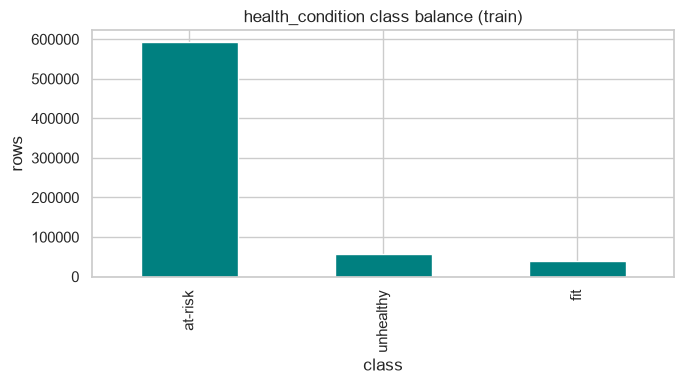

In [2]:
counts = train[TARGET].value_counts().reindex(CLASSES)
print((counts / len(train) * 100).round(2).astype(str).add(" %").to_string())
print(f"\nmax/min class ratio: {counts.max()/counts.min():.1f}")
fig, ax = plt.subplots(figsize=(7, 4))
counts.sort_values(ascending=False).plot.bar(ax=ax, color="teal")
ax.set(title="health_condition class balance (train)", xlabel="class", ylabel="rows")
fig.tight_layout(); fig.savefig(FIG / "class_balance.png", dpi=110); plt.show()

## 2. Numeric feature distributions
Ranges, shape, and how they differ by class (violin by target).

       sleep_duration  heart_rate        bmi  calorie_expenditure  step_count  exercise_duration  water_intake
count       614089.00   682255.00  676190.00            637235.00   676172.00          683187.00     646611.00
mean             6.99       75.10      22.98              2226.08     8615.95              38.75          2.19
std              1.22        8.18       2.48               347.53     3929.40              14.74          0.52
min              3.00       50.00      16.00              1200.00     1002.00               0.00          0.50
25%              6.16       69.40      21.32              2053.00     5389.00              29.20          1.84
50%              6.99       75.10      22.99              2241.00     8856.00              39.40          2.17
75%              7.81       80.70      24.66              2456.00    12114.00              49.40          2.50
max             10.00      107.70      34.82              3580.00    14999.00              99.80          4.72


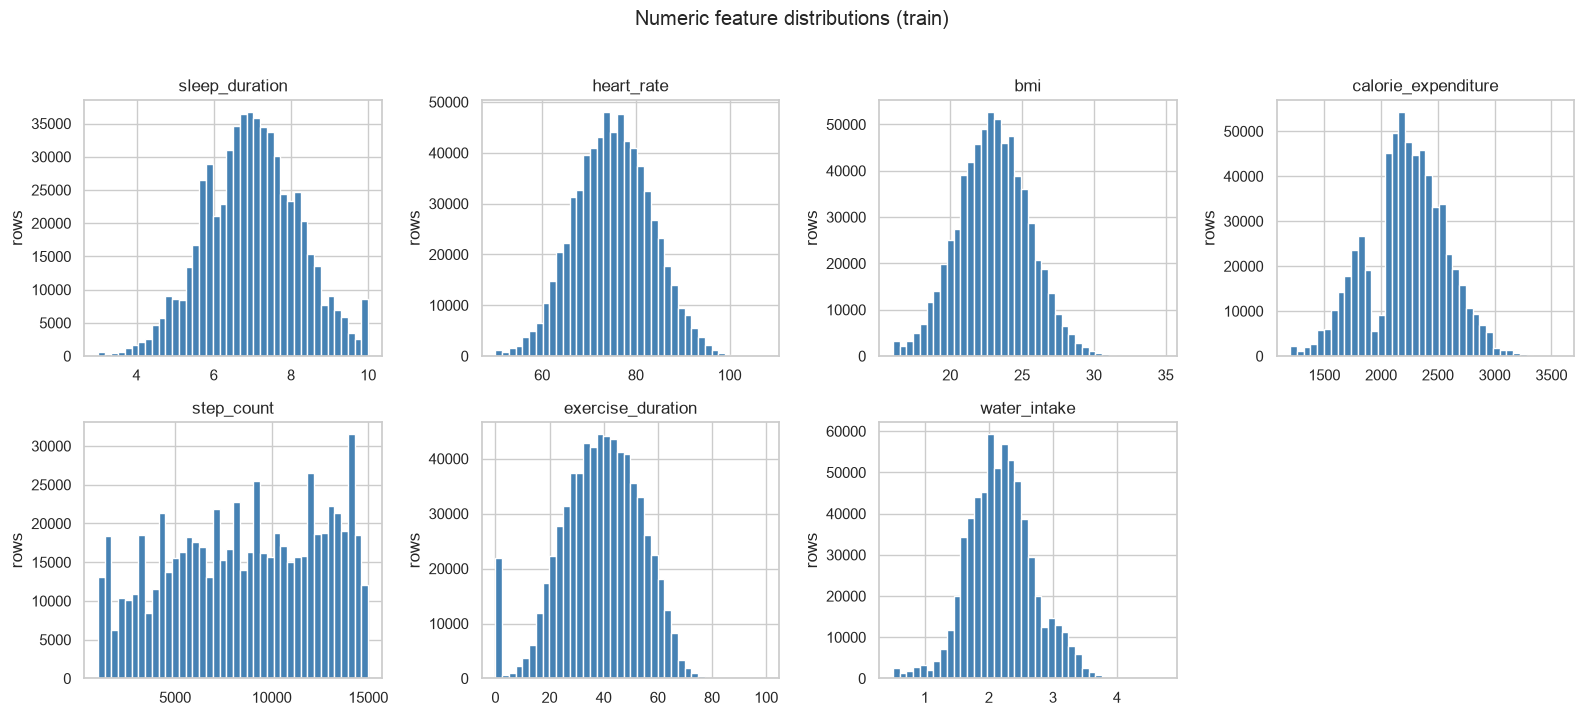

In [3]:
print(train[NUMERIC].describe().round(2).to_string())
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), NUMERIC):
    ax.hist(train[col].dropna(), bins=40, color="steelblue")
    ax.set(title=col, ylabel="rows")
axes.ravel()[-1].axis("off")
fig.suptitle("Numeric feature distributions (train)", y=1.02)
fig.tight_layout(); fig.savefig(FIG / "numeric_distributions.png", dpi=110); plt.show()

## 3. Categorical cardinality & frequency
All six categoricals are 3-level. Check level frequency.

diet_type: 3 levels (+NaN 1.0%)
diet_type
veg         33.54 %
balanced    32.88 %
non-veg     32.59 %
NaN           1.0 % 

stress_level: 3 levels (+NaN 12.0%)
stress_level
medium    37.94 %
high      25.76 %
low        24.3 %
NaN        12.0 % 

sleep_quality: 3 levels (+NaN 8.5%)
sleep_quality
average     31.0 %
poor       30.74 %
good        29.8 %
NaN         8.45 % 

physical_activity_level: 3 levels (+NaN 5.3%)
physical_activity_level
moderate     32.03 %
sedentary    31.85 %
active       30.81 %
NaN           5.31 % 

smoking_alcohol: 3 levels (+NaN 4.1%)
smoking_alcohol
yes           32.42 %
no            31.85 %
occasional    31.59 %
NaN            4.14 % 

gender: 3 levels (+NaN 3.1%)
gender
male      34.45 %
female    32.46 %
other     29.99 %
NaN         3.1 % 



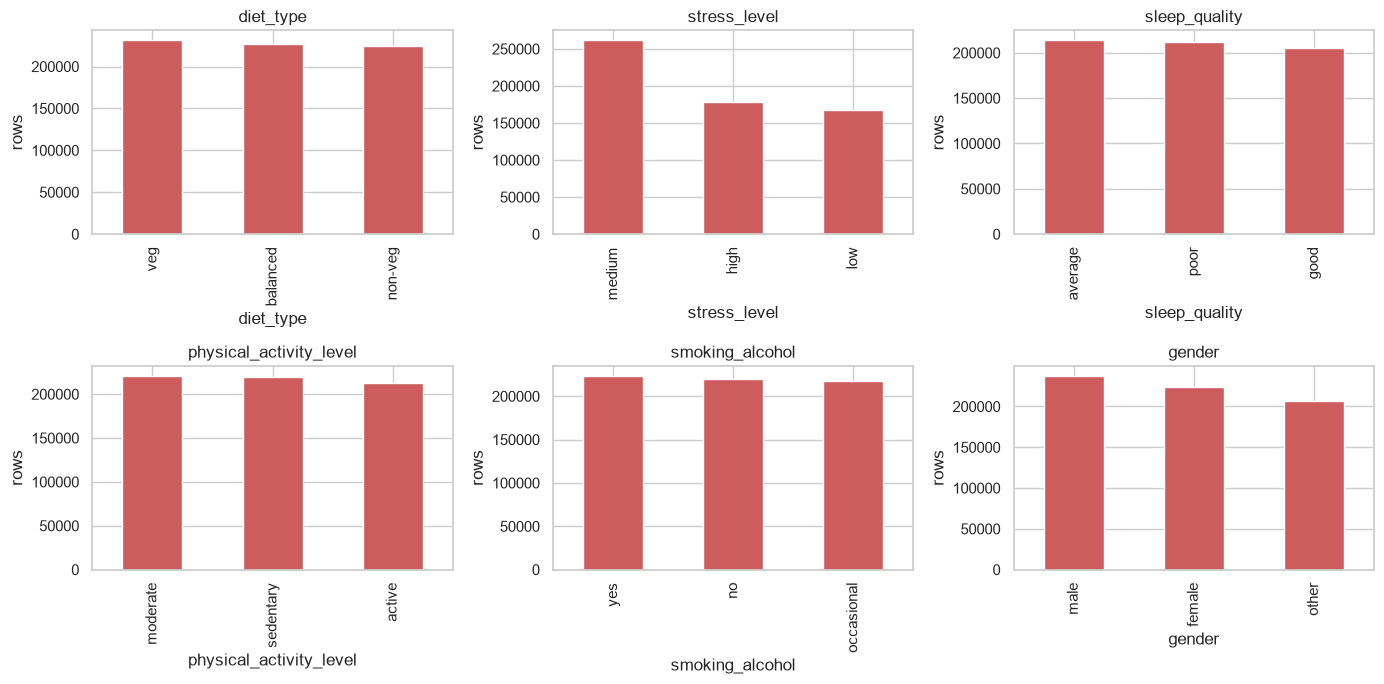

In [4]:
for col in CATEGORICAL:
    vc = train[col].value_counts(dropna=False)
    print(f"{col}: {train[col].nunique()} levels (+NaN {train[col].isna().mean()*100:.1f}%)")
    print((vc / len(train) * 100).round(2).astype(str).add(" %").to_string(), "\n")
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), CATEGORICAL):
    train[col].value_counts().plot.bar(ax=ax, color="indianred", title=col)
    ax.set_ylabel("rows")
fig.tight_layout(); fig.savefig(FIG / "categorical_frequency.png", dpi=110); plt.show()

## 4. Missingness — is it informative?

~65% of rows have at least one missing field. Two questions: (a) how much is missing per column, and
(b) does the *presence* of a missing value shift the class distribution? If missingness correlates with
the target, explicit `_isna` indicator features (the `missflag` group) should help.

per-column missing rate:
 stress_level                12.0 %
sleep_duration             11.01 %
sleep_quality               8.45 %
calorie_expenditure         7.66 %
water_intake                 6.3 %
physical_activity_level     5.31 %
smoking_alcohol             4.14 %
gender                       3.1 %
step_count                  2.02 %
bmi                         2.01 %
heart_rate                  1.14 %
exercise_duration            1.0 %
diet_type                    1.0 %

rows with >=1 missing: 49.3%

P(class | column missing) - P(class)   (biggest abs shift = most informative missingness):
                         d_at-risk   d_fit  d_unhealthy
column                                                 
bmi                         0.0301  0.0243      -0.0544
heart_rate                  0.0121 -0.0024      -0.0097
diet_type                   0.0089 -0.0068      -0.0021
exercise_duration          -0.0078  0.0027       0.0050
water_intake               -0.0036  0.0004       0.0032
step_

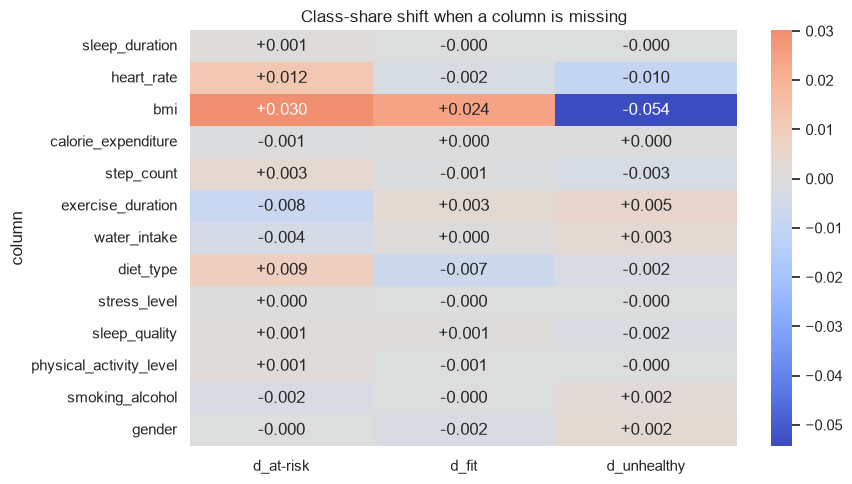

In [5]:
miss = train[NUMERIC + CATEGORICAL].isna().mean().sort_values(ascending=False)
print("per-column missing rate:\n", (miss*100).round(2).astype(str).add(" %").to_string())
print(f"\nrows with >=1 missing: {train[NUMERIC+CATEGORICAL].isna().any(axis=1).mean()*100:.1f}%")

# class balance among rows where a column is missing vs present -> lift on the minority classes
rows = []
base = train[TARGET].value_counts(normalize=True).reindex(CLASSES)
for c in NUMERIC + CATEGORICAL:
    m = train[c].isna()
    if m.sum() == 0: continue
    p_missing = train.loc[m, TARGET].value_counts(normalize=True).reindex(CLASSES).fillna(0)
    rows.append([c] + [round(p_missing[k] - base[k], 4) for k in CLASSES])
delta = pd.DataFrame(rows, columns=["column"] + [f"d_{k}" for k in CLASSES]) \
    .set_index("column")
print("\nP(class | column missing) - P(class)   (biggest abs shift = most informative missingness):")
print(delta.reindex(delta.abs().max(axis=1).sort_values(ascending=False).index).round(4).to_string())
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(delta, annot=True, fmt="+.3f", cmap="coolwarm", center=0, ax=ax)
ax.set(title="Class-share shift when a column is missing")
fig.tight_layout(); fig.savefig(FIG / "missingness_signal.png", dpi=110); plt.show()

## 5. Feature ↔ target signal

Three complementary views on how well single features separate the classes under **balanced accuracy**:
1. **Per-class numeric means** (z-scored across classes) — a heatmap of which features move with class.
2. **Mutual information** `I(feature; target)` (subsampled).
3. **Single-feature balanced accuracy** — bin the feature, estimate `P(class | bin)`, predict the
   prior-corrected argmax (`argmax_c P(c|bin)/P(c)` — the balanced-accuracy-optimal rule), and score.
   The lift over the 0.333 floor is the honest single-feature signal.

/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_1978/2147940601.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  z = (means - means.mean(0)) / means.std(0)
/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_1978/2147940601.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  z = (means - means.mean(0)) / means.std(0)


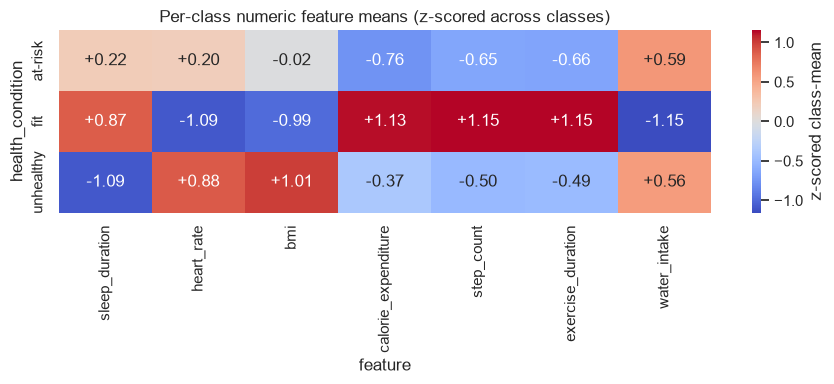

range of z-scored class means per feature (max-min):
bmi                    2.00
heart_rate             1.97
sleep_duration         1.96
calorie_expenditure    1.89
exercise_duration      1.81
step_count             1.80
water_intake           1.75


In [6]:
# 5.1 per-class z-scored numeric means
means = train.groupby(TARGET)[NUMERIC].mean()
z = (means - means.mean(0)) / means.std(0)
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(z.loc[CLASSES], annot=True, fmt="+.2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "z-scored class-mean"})
ax.set(title="Per-class numeric feature means (z-scored across classes)", xlabel="feature", ylabel=TARGET)
fig.tight_layout(); fig.savefig(FIG / "per_class_means.png", dpi=110); plt.show()
print("range of z-scored class means per feature (max-min):")
print((z.max() - z.min()).round(2).sort_values(ascending=False).to_string())

mutual information I(feature; target) [nats]:
 sleep_duration             0.15328
stress_level               0.14272
physical_activity_level    0.05656
bmi                        0.03286
step_count                 0.02325
exercise_duration          0.02279
sleep_quality              0.01398
calorie_expenditure        0.00722
water_intake               0.00707
smoking_alcohol            0.00541
heart_rate                 0.00317
diet_type                  0.00020
gender                     0.00014


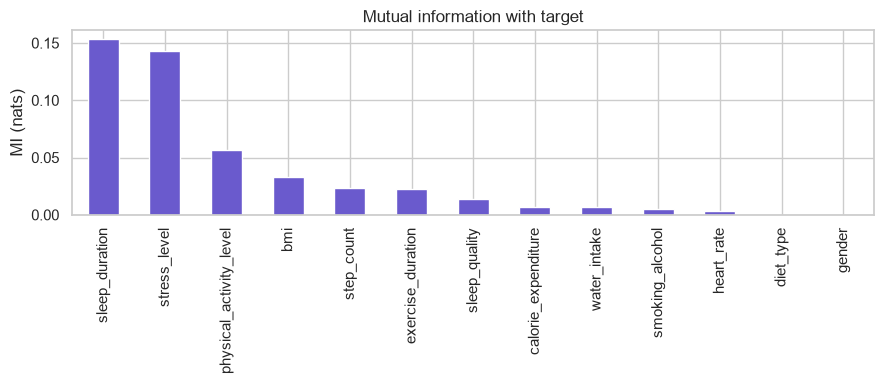

In [7]:
# 5.2 mutual information (subsample; median-impute numerics, code categoricals, NaN as its own code)
rng = np.random.default_rng(42)
sub = rng.choice(len(train), size=min(150_000, len(train)), replace=False)
Xmi = train.iloc[sub]
feat_cols = NUMERIC + CATEGORICAL
Xenc = pd.DataFrame(index=Xmi.index); discrete = []
for c in feat_cols:
    if c in CATEGORICAL:
        Xenc[c] = Xmi[c].astype("category").cat.codes; discrete.append(True)   # NaN -> -1
    else:
        Xenc[c] = Xmi[c].fillna(Xmi[c].median()); discrete.append(False)
mi = mutual_info_classif(Xenc.values, Xmi[TARGET].values, discrete_features=discrete, random_state=42)
mi_s = pd.Series(mi, index=feat_cols).sort_values(ascending=False)
print("mutual information I(feature; target) [nats]:\n", mi_s.round(5).to_string())
fig, ax = plt.subplots(figsize=(9, 4)); mi_s.plot.bar(ax=ax, color="slateblue")
ax.set(title="Mutual information with target", ylabel="MI (nats)")
fig.tight_layout(); fig.savefig(FIG / "mutual_information.png", dpi=110); plt.show()

In [8]:
# 5.3 single-feature balanced accuracy (prior-corrected argmax)
def single_feature_bacc(col, bins=None):
    s = train[col]
    if bins:
        key = pd.cut(s, bins=bins, labels=False, include_lowest=True)
    else:
        key = s.astype("category").cat.codes    # NaN -> -1 (its own bin)
    key = key.fillna(-1)
    ct = pd.crosstab(key, train[TARGET]).reindex(columns=CLASSES).fillna(0)
    P = (ct.values + 1e-9); P = P / P.sum(1, keepdims=True)
    corrected = P / prior                        # balanced-accuracy-optimal correction
    pred_code = corrected.argmax(1)
    lut = {k: pred_code[i] for i, k in enumerate(ct.index)}
    pred = np.array([lut.get(k, np.argmax(1/prior)) for k in key.values])
    return balanced_accuracy_score(yc, pred)

rows = [("(naive floor)", 1/len(CLASSES))]
for c in CATEGORICAL:
    rows.append((c, single_feature_bacc(c)))
for c in NUMERIC:
    rows.append((c + " (10 bins)", single_feature_bacc(c, bins=10)))
res = pd.DataFrame(rows, columns=["feature", "train bal_acc"]).sort_values("train bal_acc", ascending=False)
res["lift vs floor"] = res["train bal_acc"] - 1/len(CLASSES)
print(res.to_string(index=False))
print("\nNOTE: in-sample (train) balanced accuracy — an upper bound; OOF will be a touch lower.")

                      feature  train bal_acc  lift vs floor
                 stress_level       0.754119       0.420785
     sleep_duration (10 bins)       0.664901       0.331568
      physical_activity_level       0.550036       0.216702
  exercise_duration (10 bins)       0.446927       0.113594
         step_count (10 bins)       0.445619       0.112286
                sleep_quality       0.439034       0.105700
                bmi (10 bins)       0.415314       0.081981
              smoking_alcohol       0.408961       0.075627
calorie_expenditure (10 bins)       0.375359       0.042025
         heart_rate (10 bins)       0.349807       0.016473
                       gender       0.347445       0.014112
                    diet_type       0.346389       0.013055
       water_intake (10 bins)       0.344823       0.011490
                (naive floor)       0.333333       0.000000

NOTE: in-sample (train) balanced accuracy — an upper bound; OOF will be a touch lower.


## 6. Duplicates & label-conflict ceiling
Exact-duplicate feature rows, and feature vectors mapping to >1 class (irreducible ambiguity).

In [9]:
feat_cols = NUMERIC + CATEGORICAL
dup = train.duplicated(subset=feat_cols).sum()
print(f"exact-duplicate feature rows: {dup} ({dup/len(train)*100:.2f}%)")
grp = train.groupby(feat_cols, dropna=False, observed=True)[TARGET].nunique()
ambig_rows = int(train.groupby(feat_cols, dropna=False, observed=True)[TARGET]
                 .transform("nunique").gt(1).sum())
print(f"distinct feature vectors: {grp.shape[0]:,}")
print(f"vectors mapping to >1 class: {(grp>1).sum():,} groups, {ambig_rows:,} rows "
      f"({ambig_rows/len(train)*100:.2f}%)")

exact-duplicate feature rows: 0 (0.00%)


distinct feature vectors: 690,088
vectors mapping to >1 class: 0 groups, 0 rows (0.00%)


## 7. Train vs test drift
Test labels are hidden; compare feature distributions (KS numeric, share deltas categorical, missing-rate deltas).

numeric KS train-vs-test p-values:
  sleep_duration       p=0.595
  heart_rate           p=0.386
  bmi                  p=0.959
  calorie_expenditure  p=0.652
  step_count           p=0.213
  exercise_duration    p=0.634
  water_intake         p=0.025
features with KS p<0.01: 0 / 7
diet_type: max |share delta| = 0.083 pp
stress_level: max |share delta| = 0.138 pp
sleep_quality: max |share delta| = 0.145 pp
physical_activity_level: max |share delta| = 0.904 pp
smoking_alcohol: max |share delta| = 0.213 pp
gender: max |share delta| = 3.415 pp

missing-rate drift (pp):
 sleep_duration            -0.0
heart_rate                -0.0
bmi                       -0.0
calorie_expenditure        0.0
step_count                -0.0
exercise_duration          0.0
water_intake              -0.0
diet_type                  0.0
stress_level              -0.0
sleep_quality             -0.0
physical_activity_level    0.0
smoking_alcohol           -0.0
gender                     0.0


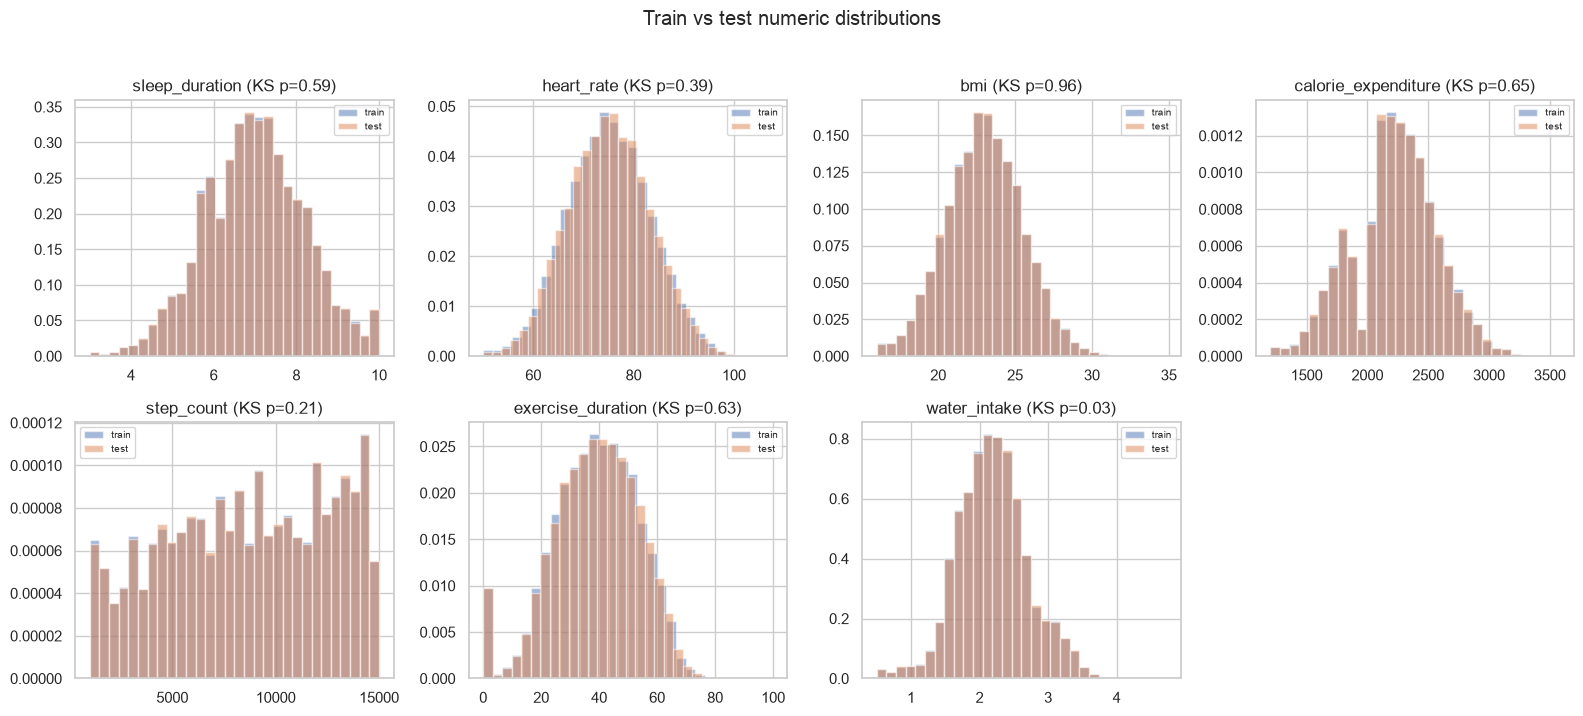

In [10]:
ks = {c: stats.ks_2samp(train[c].dropna(), test[c].dropna()).pvalue for c in NUMERIC}
print("numeric KS train-vs-test p-values:")
for c, p in ks.items(): print(f"  {c:20s} p={p:.3f}")
print("features with KS p<0.01:", sum(p < 0.01 for p in ks.values()), "/", len(ks))
for c in CATEGORICAL:
    d = (train[c].value_counts(normalize=True) - test[c].value_counts(normalize=True)).abs().max()
    print(f"{c}: max |share delta| = {d*100:.3f} pp")
mr = pd.DataFrame({"train_miss": train[feat_cols].isna().mean(),
                   "test_miss": test[feat_cols].isna().mean()})
mr["delta_pp"] = (mr["test_miss"] - mr["train_miss"]) * 100
print("\nmissing-rate drift (pp):\n", mr["delta_pp"].round(3).to_string())

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), NUMERIC):
    ax.hist(train[col].dropna(), bins=30, alpha=0.5, density=True, label="train")
    ax.hist(test[col].dropna(), bins=30, alpha=0.5, density=True, label="test")
    ax.set(title=f"{col} (KS p={ks[col]:.2f})"); ax.legend(fontsize=7)
axes.ravel()[-1].axis("off")
fig.suptitle("Train vs test numeric distributions", y=1.02)
fig.tight_layout(); fig.savefig(FIG / "train_test_drift.png", dpi=110); plt.show()

## 8. Correlation
Linear correlation among numeric features (redundancy is worth knowing even though trees use interactions).

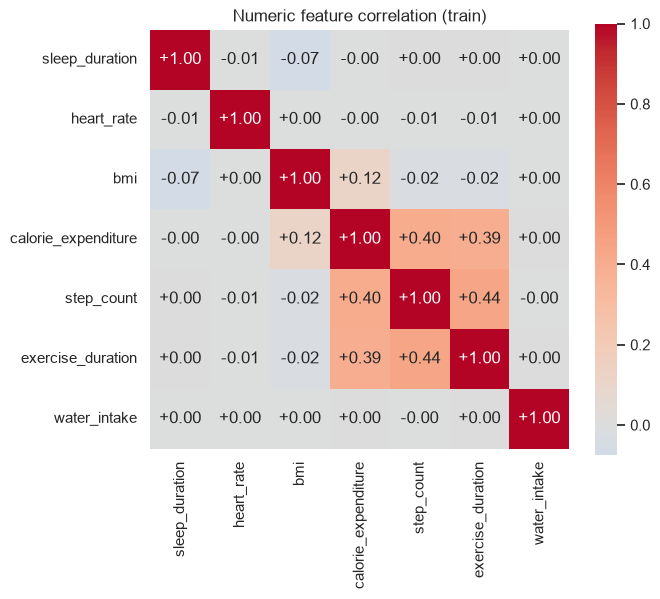

max |off-diagonal| correlation: 0.438


In [11]:
corr = train[NUMERIC].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt="+.2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set(title="Numeric feature correlation (train)")
fig.tight_layout(); fig.savefig(FIG / "numeric_correlation.png", dpi=110); plt.show()
print("max |off-diagonal| correlation:",
      round(corr.where(~np.eye(len(corr), dtype=bool)).abs().max().max(), 3))

## Summary
Key numbers and modeling implications are written up in **`reports/EDA_FINDINGS.md`**.